# Análise de Sentimentos com NLP
## Classificação de Revisões do IMDB

**Dataset**: IMDB Movie Reviews - 50.000 revisões balanceadas (25.000 positivas, 25.000 negativas)

## Metodologia

### 1. Pré-processamento
- **Bag of Words (BoW)**: Representação baseada em contagem de palavras
- **TF-IDF**: Representação que pondera a importância das palavras

### 2. Modelo
- **Regressão Logística**: Classificador linear eficiente para texto
- **Configuração**: max_iter=1000 para garantir convergência

### 3. Avaliação
- Acurácia
- Relatório de classificação (precision, recall, F1-score)

In [82]:
import os
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [83]:
def carregar_dados(base_path):
    textos = []
    labels = []

    for label, sentimento in enumerate(["neg", "pos"]):
        caminho = os.path.join(base_path, sentimento)

        for arquivo in os.listdir(caminho):
            if arquivo.endswith(".txt"):
                with open(os.path.join(caminho, arquivo), encoding="utf-8") as f:
                    textos.append(f.read())
                    labels.append(label)

    return textos, labels


In [84]:
X_train, y_train = carregar_dados("../data/raw/imdb/train")
X_test, y_test = carregar_dados("../data/raw/imdb/test")

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 25000
Teste: 25000


## Bag of Words

In [85]:
vectorizer_bow = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)

print("Dimensão BoW:", X_train_bow.shape)

Dimensão BoW: (25000, 156816)


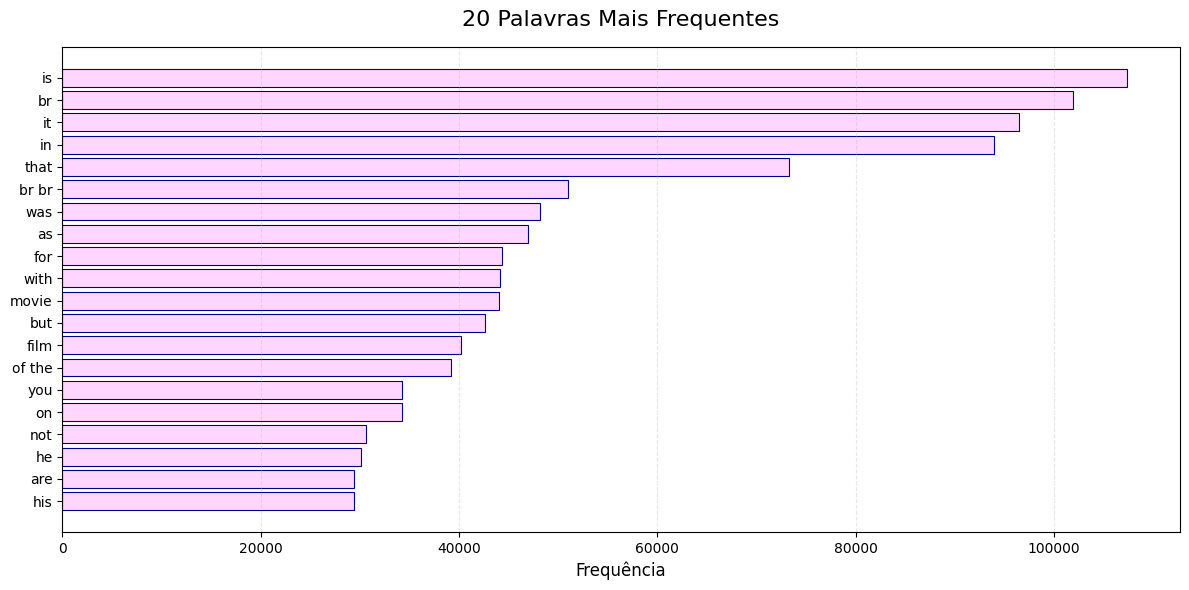

In [86]:
# Soma as ocorrências de cada palavra
word_counts = np.array(X_train_bow.sum(axis=0)).flatten()
words = vectorizer_bow.get_feature_names_out()

# Top N palavras mais frequentes
top_n = 20
top_indices = np.argsort(word_counts)[-top_n:]
top_words = [words[i] for i in top_indices]
top_counts = word_counts[top_indices]

plt.figure(figsize=(12, 6))
bars = plt.barh(range(top_n), top_counts, color='#ffd6ff', edgecolor='darkblue', linewidth=0.8)
plt.yticks(range(top_n), top_words)
plt.xlabel('Frequência', fontsize=12)
plt.title(f'{top_n} Palavras Mais Frequentes', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

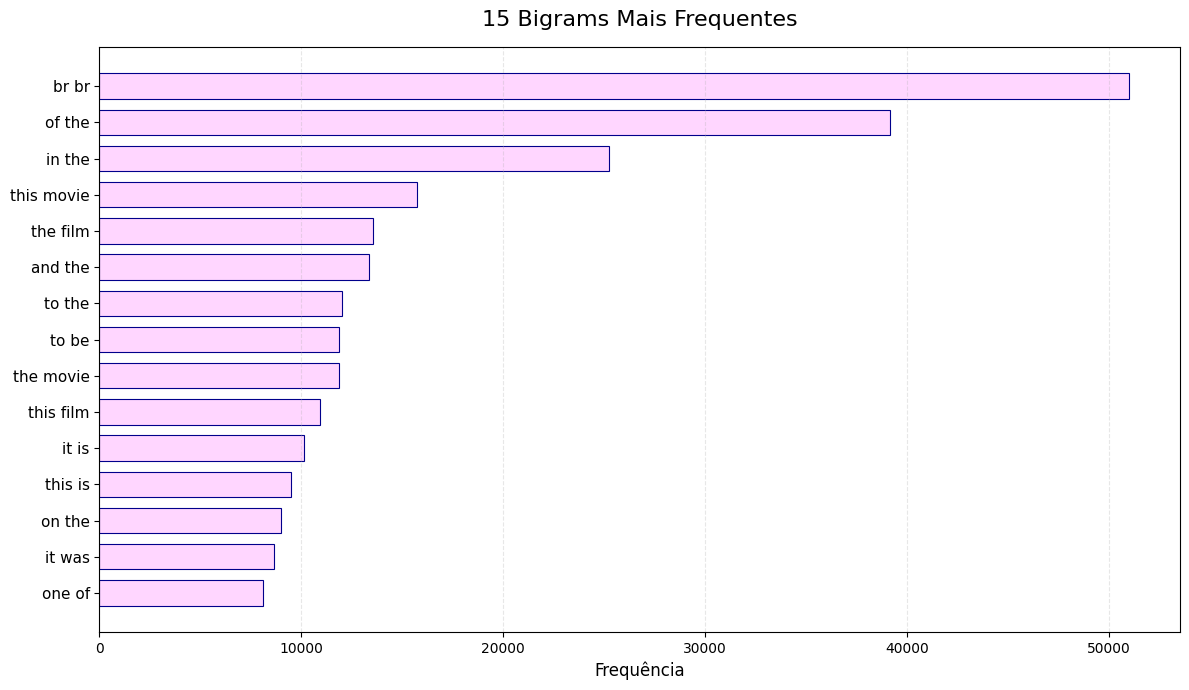

Total de bigrams únicos: 129549
Bigrams com frequência >= 5: 129549


In [87]:
# Extrai apenas bigrams
vectorizer_bigrams = CountVectorizer(ngram_range=(2, 2), min_df=5)
X_bigrams = vectorizer_bigrams.fit_transform(X_train)
bigram_counts = np.array(X_bigrams.sum(axis=0)).flatten()
bigrams = vectorizer_bigrams.get_feature_names_out()

# Top bigrams - CORREÇÃO: usar len(top_bigrams) em vez de top_n
top_n_bigrams = 15  # Defina o número de bigrams que quer mostrar
top_bigrams_idx = np.argsort(bigram_counts)[-top_n_bigrams:]
top_bigrams = [bigrams[i] for i in top_bigrams_idx]
top_bigram_counts = bigram_counts[top_bigrams_idx]

plt.figure(figsize=(12, 7))

# CORREÇÃO: usar len(top_bigrams) no range e top_bigram_counts nos valores
bars = plt.barh(range(len(top_bigrams)), top_bigram_counts, 
                color='#ffd6ff', 
                edgecolor='darkblue', 
                linewidth=0.8,
                height=0.7)

plt.yticks(range(len(top_bigrams)), top_bigrams, fontsize=11)
plt.xlabel('Frequência', fontsize=12)
plt.title(f'{len(top_bigrams)} Bigrams Mais Frequentes', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Estatísticas
print(f"Total de bigrams únicos: {len(bigrams)}")
print(f"Bigrams com frequência >= 5: {np.sum(bigram_counts >= 5)}")

Número de palavras no vocabulário: 156816
Shape do word_counts: (156816,)


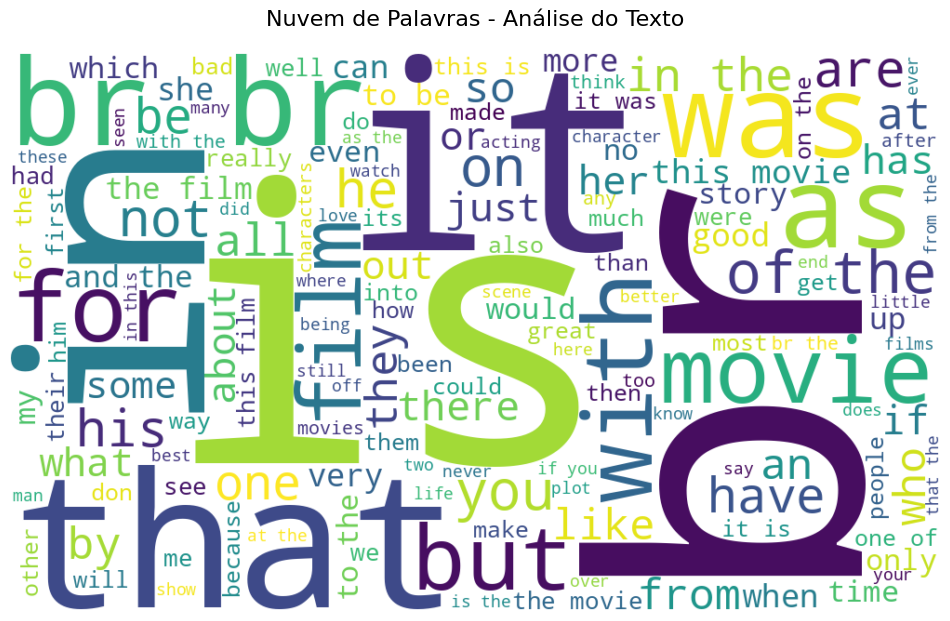

In [88]:
from wordcloud import WordCloud

# 1. PRIMEIRO: Extrair as palavras e frequências da sua matriz BoW
words = vectorizer_bow.get_feature_names_out()  # Nomes das features (palavras)
word_counts = np.array(X_train_bow.sum(axis=0)).flatten()  # Soma total de cada palavra

# 2. Verificar se as variáveis foram criadas
print(f"Número de palavras no vocabulário: {len(words)}")
print(f"Shape do word_counts: {word_counts.shape}")

# 3. AGORA criar o dicionário para a wordcloud
freq_dict = dict(zip(words, word_counts))

# 4. Criar a wordcloud
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(
    width=1000, 
    height=600,
    background_color='white',
    max_words=150,
    colormap='viridis',
    contour_width=1,
    contour_color='steelblue'
).generate_from_frequencies(freq_dict)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras - Análise do Texto', fontsize=16, pad=20)
plt.show()

In [89]:
pipelines_bow = {
    "Logistic Regression (BoW)": Pipeline([
        ("vect", CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    
    "Naive Bayes (BoW)": Pipeline([
        ("vect", CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)),
        ("clf", MultinomialNB())
    ]),
    
    "Linear SVM (BoW)": Pipeline([
        ("vect", CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)),
        ("clf", LinearSVC())
    ])
}

## TF-IDF

In [92]:
vectorizer_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

print("Dimensão TF-IDF:", X_train_tfidf.shape)

Dimensão TF-IDF: (25000, 156816)


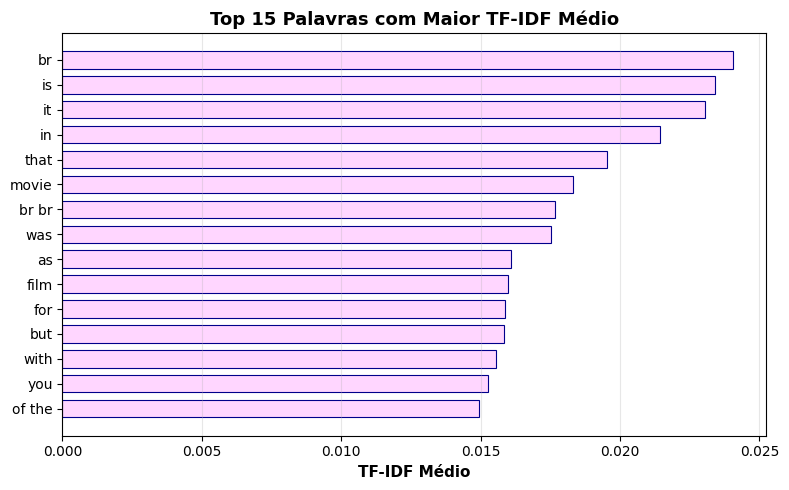

In [103]:
# Ordena do maior para o menor
top_tfidf_idx = np.argsort(tfidf_means)[-top_n_tfidf:][::-1]
top_tfidf_words = [tfidf_words[i] for i in top_tfidf_idx]
top_tfidf_vals = tfidf_means[top_tfidf_idx]

plt.figure(figsize=(8, 5))
plt.barh(
    range(len(top_tfidf_words)),
    top_tfidf_vals,
    color="#ffd6ff" ,
    edgecolor='darkblue',
    linewidth=0.8,
    height=0.7
)

plt.yticks(range(len(top_tfidf_words)), top_tfidf_words, fontsize=10)
plt.xlabel('TF-IDF Médio', fontsize=11, fontweight='bold')
plt.title(f'Top {top_n_tfidf} Palavras com Maior TF-IDF Médio',
          fontsize=13, fontweight='bold')

# Mantém o maior no topo
plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
pipelines_tfidf = {
    "Logistic Regression (TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1,2),
            min_df=5,
            max_df=0.9,
            sublinear_tf=True
        )),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    
    "Naive Bayes (TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1,2),
            min_df=5,
            max_df=0.9,
            sublinear_tf=True
        )),
        ("clf", MultinomialNB())
    ]),
    
    "Linear SVM (TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1,2),
            min_df=5,
            max_df=0.9,
            sublinear_tf=True
        )),
        ("clf", LinearSVC())
    ])
}

In [100]:
from sklearn.metrics import accuracy_score

resultados = []

for nome, pipeline in {**pipelines_bow, **pipelines_tfidf}.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nome,
        "Acurácia": acc
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="Acurácia", ascending=False)
df_resultados


/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Modelo,Acurácia
5,Linear SVM (TF-IDF),0.90424
3,Logistic Regression (TF-IDF),0.90008
0,Logistic Regression (BoW),0.89360
2,Linear SVM (BoW),0.88560
4,Naive Bayes (TF-IDF),0.87308
1,Naive Bayes (BoW),0.85828


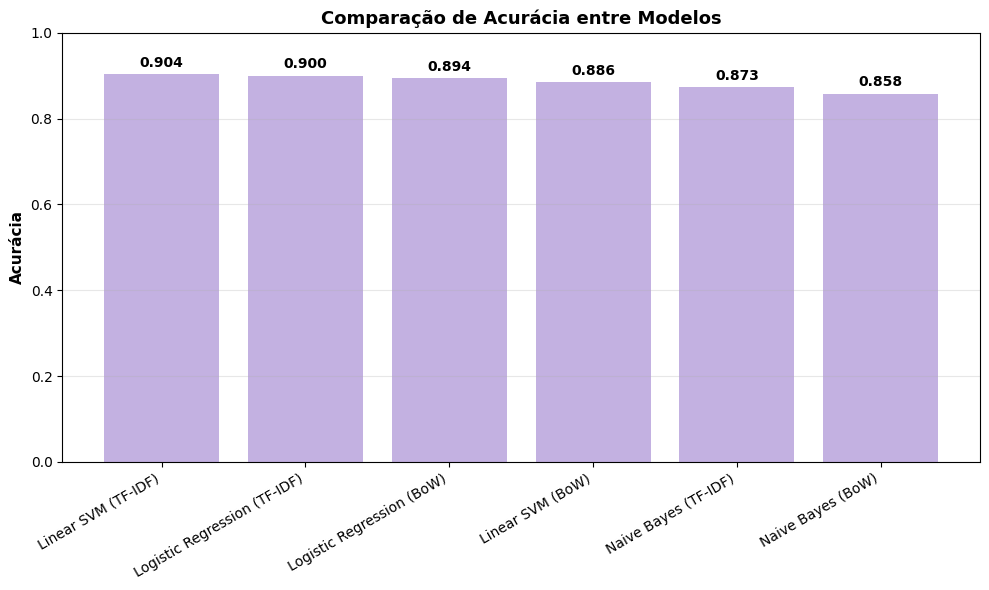

In [119]:


# Garante que está ordenado
df_plot = df_resultados.sort_values(by="Acurácia", ascending=False)

plt.figure(figsize=(10, 6))

# Tons pastel (um por barra)
colors = [
    "#C3B1E1",  # roxo pastel
]

bars = plt.bar(
    df_plot["Modelo"],
    df_plot["Acurácia"],
    color=colors[:len(df_plot)]
)

plt.ylabel("Acurácia", fontsize=11, fontweight="bold")
plt.title("Comparação de Acurácia entre Modelos", fontsize=13, fontweight="bold")

plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")

# Valores em cima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


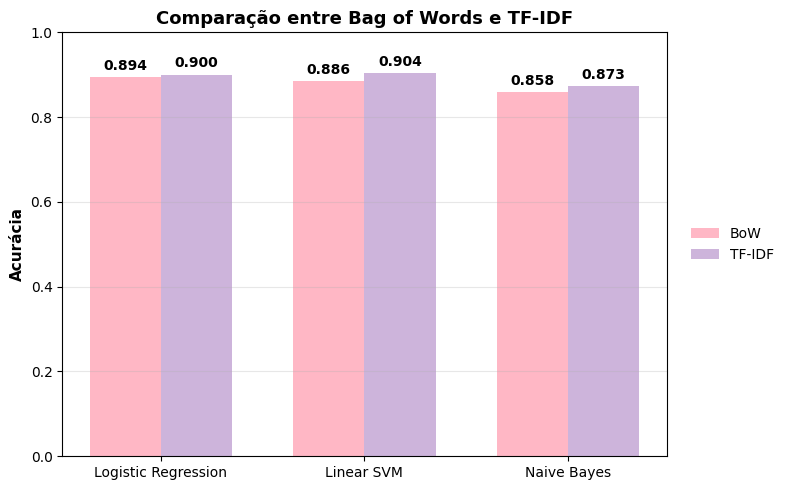

In [118]:
modelos = ["Logistic Regression", "Linear SVM", "Naive Bayes"]

bow_acc = [
    df_resultados[df_resultados["Modelo"] == "Logistic Regression (BoW)"]["Acurácia"].values[0],
    df_resultados[df_resultados["Modelo"] == "Linear SVM (BoW)"]["Acurácia"].values[0],
    df_resultados[df_resultados["Modelo"] == "Naive Bayes (BoW)"]["Acurácia"].values[0]
]

tfidf_acc = [
    df_resultados[df_resultados["Modelo"] == "Logistic Regression (TF-IDF)"]["Acurácia"].values[0],
    df_resultados[df_resultados["Modelo"] == "Linear SVM (TF-IDF)"]["Acurácia"].values[0],
    df_resultados[df_resultados["Modelo"] == "Naive Bayes (TF-IDF)"]["Acurácia"].values[0]
]

x = np.arange(len(modelos))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    bow_acc,
    width,
    label="BoW",
    color="#FFB7C5"  
)

bars2 = plt.bar(
    x + width/2,
    tfidf_acc,
    width,
    label="TF-IDF",
    color="#CDB4DB"  
)

plt.ylabel("Acurácia", fontsize=11, fontweight="bold")
plt.title("Comparação entre Bag of Words e TF-IDF", fontsize=13, fontweight="bold")
plt.xticks(x, modelos)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)


# Valores em cima das barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()


<Figure size 500x400 with 0 Axes>

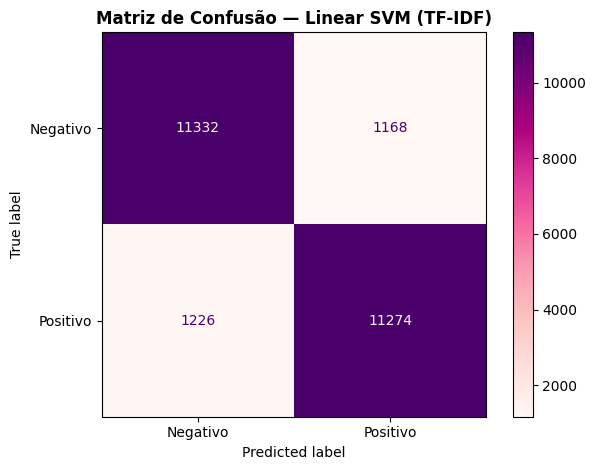

<Figure size 500x400 with 0 Axes>

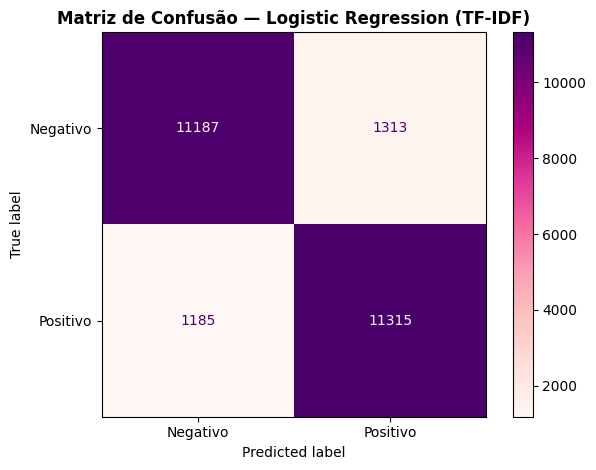

<Figure size 500x400 with 0 Axes>

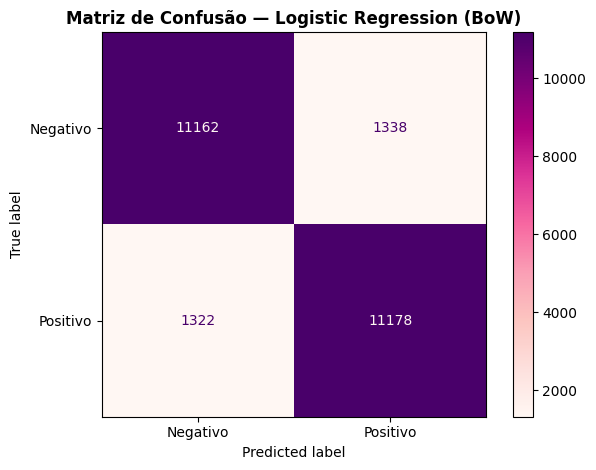

/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


<Figure size 500x400 with 0 Axes>

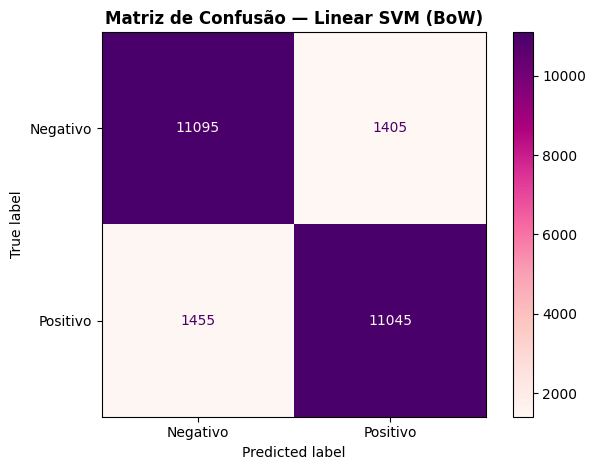

<Figure size 500x400 with 0 Axes>

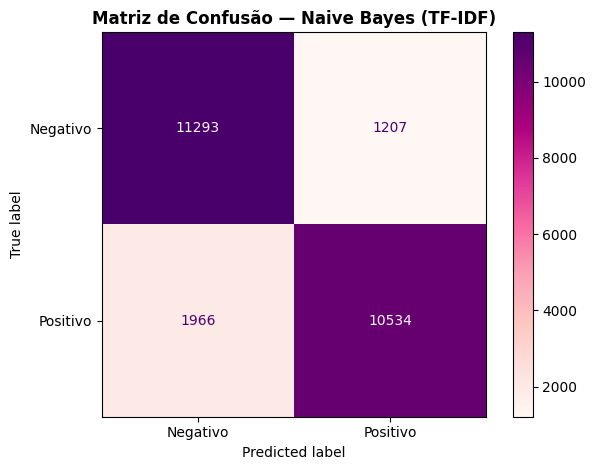

<Figure size 500x400 with 0 Axes>

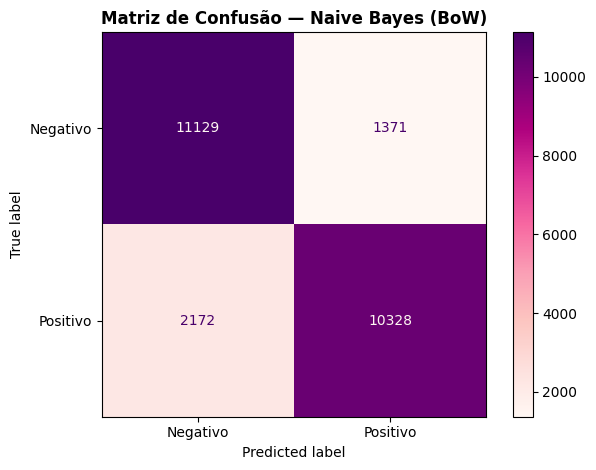

In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

todos_modelos = {
    "Linear SVM (TF-IDF)": pipelines_tfidf["Linear SVM (TF-IDF)"],
    "Logistic Regression (TF-IDF)": pipelines_tfidf["Logistic Regression (TF-IDF)"],
    "Logistic Regression (BoW)": pipelines_bow["Logistic Regression (BoW)"],
    "Linear SVM (BoW)": pipelines_bow["Linear SVM (BoW)"],
    "Naive Bayes (TF-IDF)": pipelines_tfidf["Naive Bayes (TF-IDF)"],
    "Naive Bayes (BoW)": pipelines_bow["Naive Bayes (BoW)"]
}

for nome, modelo in todos_modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negativo", "Positivo"]
    )
    
    plt.figure(figsize=(5, 4))
    disp.plot(
        cmap="RdPu",          
        values_format="d"
    )
    plt.title(f"Matriz de Confusão — {nome}", fontsize=12, fontweight="bold")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metricas = []

todos_modelos = {**pipelines_bow, **pipelines_tfidf}

for nome, pipeline in todos_modelos.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    metricas.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

df_metricas = pd.DataFrame(metricas).sort_values(by="F1-score", ascending=False)
df_metricas


/home/enginelab/Documentos/repos/projeto-ciencia-dos-dados/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Modelo,Acurácia,Precision,Recall,F1-score
5,Linear SVM (TF-IDF),0.90424,0.906124,0.90192,0.904017
3,Logistic Regression (TF-IDF),0.90008,0.896025,0.90520,0.900589
0,Logistic Regression (BoW),0.89360,0.893097,0.89424,0.893668
2,Linear SVM (BoW),0.88564,0.887158,0.88368,0.885415
4,Naive Bayes (TF-IDF),0.87308,0.897198,0.84272,0.869106
1,Naive Bayes (BoW),0.85828,0.882810,0.82624,0.853589


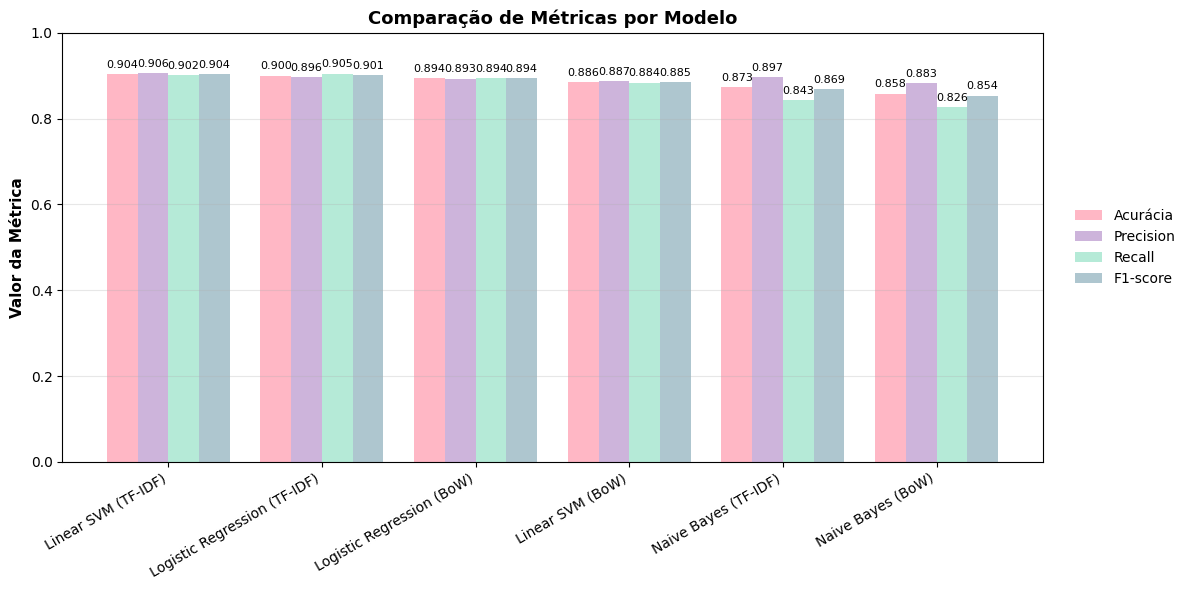

In [121]:

df_plot = df_metricas.copy()

x = np.arange(len(df_plot))
width = 0.2

plt.figure(figsize=(12, 6))

bars_acc = plt.bar(
    x - 1.5*width,
    df_plot["Acurácia"],
    width,
    label="Acurácia",
    color="#FFB7C5"  # rosa pastel
)

bars_prec = plt.bar(
    x - 0.5*width,
    df_plot["Precision"],
    width,
    label="Precision",
    color="#CDB4DB"  # lilás pastel
)

bars_rec = plt.bar(
    x + 0.5*width,
    df_plot["Recall"],
    width,
    label="Recall",
    color="#B5EAD7"  # verde pastel
)

bars_f1 = plt.bar(
    x + 1.5*width,
    df_plot["F1-score"],
    width,
    label="F1-score",
    color="#AEC6CF"  # azul pastel
)

plt.ylabel("Valor da Métrica", fontsize=11, fontweight="bold")
plt.title("Comparação de Métricas por Modelo", fontsize=13, fontweight="bold")
plt.xticks(x, df_plot["Modelo"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

# Legenda fora
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Valores em cima das barras
for bars in [bars_acc, bars_prec, bars_rec, bars_f1]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()


In [113]:
# Usa Logistic Regression com TF-IDF
modelo = pipelines_tfidf["Logistic Regression (TF-IDF)"]
modelo.fit(X_train, y_train)

# Extrai o classificador e o vetorizador
clf = modelo.named_steps["clf"]
vectorizer = modelo.named_steps["tfidf"]

# Coeficientes do modelo
coef = clf.coef_[0]
feature_names = vectorizer.get_feature_names_out()

In [114]:
top_n = 15

# Palavras mais negativas
top_neg_idx = np.argsort(coef)[:top_n]
top_neg_words = feature_names[top_neg_idx]
top_neg_vals = coef[top_neg_idx]

# Palavras mais positivas
top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_pos_words = feature_names[top_pos_idx]
top_pos_vals = coef[top_pos_idx]


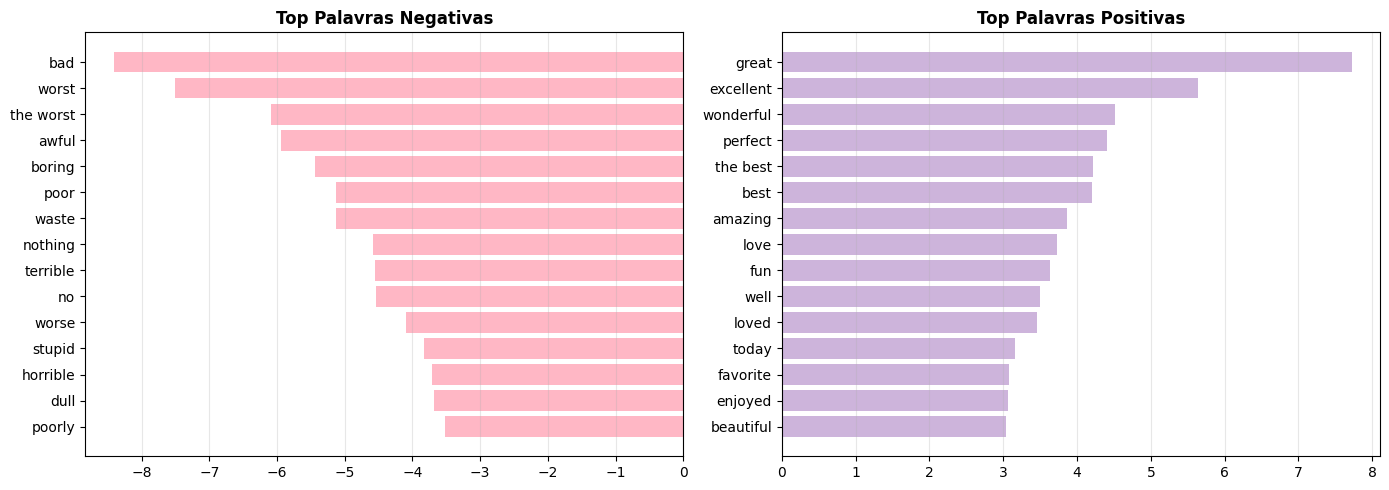

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Negativas
axes[0].barh(
    range(top_n),
    top_neg_vals,
    color="#FFB7C5"  # rosa pastel
)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_neg_words, fontsize=10)
axes[0].set_title("Top Palavras Negativas", fontsize=12, fontweight="bold")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)

# Positivas
axes[1].barh(
    range(top_n),
    top_pos_vals,
    color="#CDB4DB"  # rosa/lilás pastel
)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_pos_words, fontsize=10)
axes[1].set_title("Top Palavras Positivas", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
